Vi revisitar det här fina AirBnb-setet för att se vad vi kan åstadkomma med hjälp av neurala nätverk! 

In [ ]:
# Vi vill veta vad vi kan göra för analys baserat på text-variablerna (ostrukturerade datan) i datasetet, i synnerhet description.

Ursprunglig storlek: 4955 rader
Efter rensning: 3030 rader kvar
Pris: 120 → 3905 SEK (medel 1362)
Train: 2424, Test: 606

Bygger TF-IDF-vektorer...
  name                     : 100 features (max 100)
  description              : 200 features (max 200)
  amenities                : 100 features (max 100)
  neighborhood_overview    :  50 features (max 50)
  host_about               :  50 features (max 50)

Final feature matrix:
  Train: (2424, 500)
  Test:  (606, 500)
  Totalt 500 features (bara text)

Modell — antal parametrar: 74,497
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1295.1348 - mae: 1295.1348 - val_loss: 917.5616 - val_mae: 917.5616
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 673.4406 - mae: 673.4406 - val_loss: 606.7763 - val_mae: 606.7763
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 607.1312 - mae: 607.1312 - val_loss: 570.7527 - val_mae: 570.7527
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 573.3020 - mae: 573.3020 

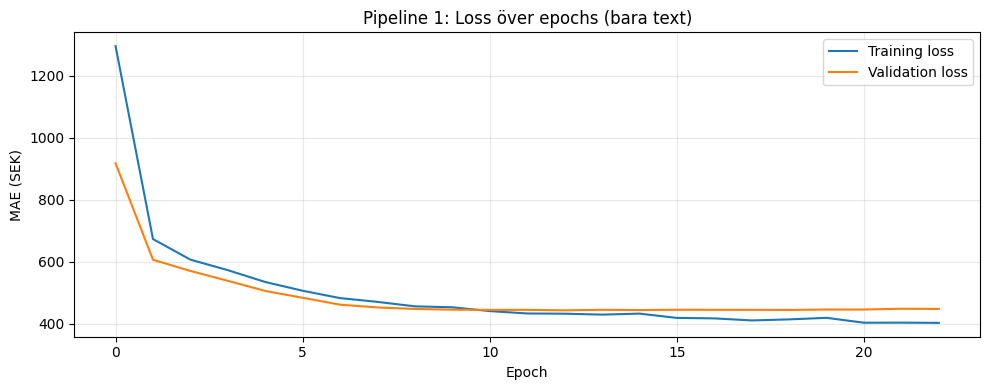

In [3]:
# ============================================================
# PIPELINE 1: BARA TEXT
# Förbehandling: TF-IDF på 5 textfält
# Modell: Sequential (Iris-stil)
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================
# STEG 1: Ladda data
# ============================================================
df = pd.read_csv("data/airbnb_listings_stockholm_detailed.csv")
print(f"Ursprunglig storlek: {len(df)} rader")

target = "price"
text_cols = ["name", "description", "amenities",
             "neighborhood_overview", "host_about"]

# ============================================================
# STEG 2: Rensa pris
# ============================================================
df[target] = (
    df[target].astype(str)
              .str.replace(r"[\$,]", "", regex=True)
              .str.strip()
              .replace("", np.nan)
              .astype(float)
)
df = df.dropna(subset=[target])

# ============================================================
# STEG 3: Rensa textfält (NaN → "okänt", ta bort unicode)
# ============================================================
for c in text_cols:
    df[c] = (
        df[c]
        .fillna("okänt")
        .astype(str)
        .str.strip()
        .apply(lambda s: s.encode("latin-1", errors="ignore").decode("latin-1"))
        .replace("", "okänt")
        .replace("nan", "okänt")
    )

# ============================================================
# STEG 4: Stryp pris-outliers
# ============================================================
df = df[(df[target] >= 10) & (df[target] <= df[target].quantile(0.95))]

print(f"Efter rensning: {len(df)} rader kvar")
print(f"Pris: {df[target].min():.0f} → {df[target].max():.0f} SEK (medel {df[target].mean():.0f})")

# ============================================================
# STEG 5: Train/test split
# ============================================================
y = df[target].values.astype("float32")

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train_df)}, Test: {len(X_test_df)}")

# ============================================================
# STEG 6: TF-IDF på varje textfält
# ============================================================
print("\nBygger TF-IDF-vektorer...")

tfidf_settings = {
    "name":                  100,
    "description":           200,
    "amenities":             100,
    "neighborhood_overview": 50,
    "host_about":            50,
}

tfidf_vectorizers = {}
tfidf_train = []
tfidf_test = []

for col, max_feat in tfidf_settings.items():
    tfidf = TfidfVectorizer(
        max_features=max_feat,
        stop_words="english",
        lowercase=True,
        min_df=5,
        ngram_range=(1, 1))
    
    train_vec = tfidf.fit_transform(X_train_df[col].values)
    test_vec  = tfidf.transform(X_test_df[col].values)
    
    tfidf_vectorizers[col] = tfidf
    tfidf_train.append(train_vec)
    tfidf_test.append(test_vec)
    print(f"  {col:25s}: {train_vec.shape[1]:>3} features (max {max_feat})")

# ============================================================
# STEG 7: Kombinera alla TF-IDF-matriser
# ============================================================
X_train_text = hstack(tfidf_train).toarray().astype("float32")
X_test_text  = hstack(tfidf_test).toarray().astype("float32")

print(f"\nFinal feature matrix:")
print(f"  Train: {X_train_text.shape}")
print(f"  Test:  {X_test_text.shape}")
print(f"  Totalt {X_train_text.shape[1]} features (bara text)")

# ============================================================
# STEG 8: Bygg Sequential modell
# ============================================================
model_text = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_text.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)              # regression: 1 neuron, linjär
])

model_text.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"])

print(f"\nModell — antal parametrar: {model_text.count_params():,}")

# ============================================================
# STEG 9: Träna med EarlyStopping
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True)

history_text = model_text.fit(
    X_train_text, y_train,
    validation_data=(X_test_text, y_test),
    epochs=100, batch_size=32,
    callbacks=[early_stop],
    verbose=1)

# ============================================================
# STEG 10: Utvärdera
# ============================================================
y_pred_text = model_text.predict(X_test_text).flatten()
mae_text = np.mean(np.abs(y_pred_text - y_test))
rmse_text = np.sqrt(np.mean((y_pred_text - y_test) ** 2))

mean_pred = y_train.mean()
mae_base = np.mean(np.abs(y_test - mean_pred))

mape  = np.mean(np.abs((y_test - y_pred_text) / y_test)) * 100
r2    = r2_score(y_test, y_pred_text)
medae = np.median(np.abs(y_test - y_pred_text))


print("\n" + "=" * 50)
print("PIPELINE 1 — ENBART TEXT")
print("=" * 50)
print(f"Antal features:        {X_train_text.shape[1]}")
print(f"MAE 'gissa medel':     {mae_base:.1f} SEK")
print(f"MAE pipeline 1 (text): {mae_text:.1f} SEK")
print(f"RMSE:                  {rmse_text:.1f} SEK")
print(f"Relativt fel:          {mae_text/y_test.mean()*100:.1f}%")
print(f"Median AE: {medae:>7.1f} SEK   (typiskt fel — robust)")
print(f"MAPE:      {mape:>7.1f} %     (procentuellt fel)")
print(f"R²:        {r2:>7.3f}         (förklarad variation)")

# ============================================================
# STEG 11: Plotta loss-kurvan
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(history_text.history["loss"], label="Training loss")
plt.plot(history_text.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Pipeline 1: Loss över epochs (bara text)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
"""
Analys av loss-kurvan
Bilden visar en lärobokstypisk träningskurva:

Båda kurvor dyker brant under första epochs — modellen lär sig snabbt grunderna
Båda planar ut runt epoch 10 — modellen har hittat sin nivå
Validation loss (~445) ligger lätt över training loss (~400) — en hälsosam liten skillnad
Ingen overfitting — validation loss går inte upp, bara stannar
EarlyStopping slog till runt epoch 22 (patience=10 från bästa val_loss runt epoch 12)

Det här är en välbeteende modell — visar att du satt regulariseringen (dropout) lagom.
"""

Trial 64 Complete [00h 00m 19s]
val_mae: 461.51397705078125

Best val_mae So Far: 458.4985046386719
Total elapsed time: 00h 19m 53s

BÄSTA HYPERPARAMETRAR FUNNA
  Neuroner lager 1:        128
  Dropout lager 1:         0.4
  Neuroner lager 2:        128
  Dropout lager 2:         0.2
  Neuroner lager 3:        64
  Learning rate:           0.0005

Bästa modell — antal parametrar: 88,961

Tränar bästa modellen i upp till 100 epochs...
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1342.9050 - mae: 1342.9050 - val_loss: 1186.2417 - val_mae: 1186.2417
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 818.0967 - mae: 818.0967 - val_loss: 623.2845 - val_mae: 623.2845
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 621.7104 - mae: 621.7104 - val_loss: 594.2856 - val_mae: 594.2856
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 592.5949 - mae: 592.5949 - val_loss: 569.6529 - val_mae: 569.6529
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

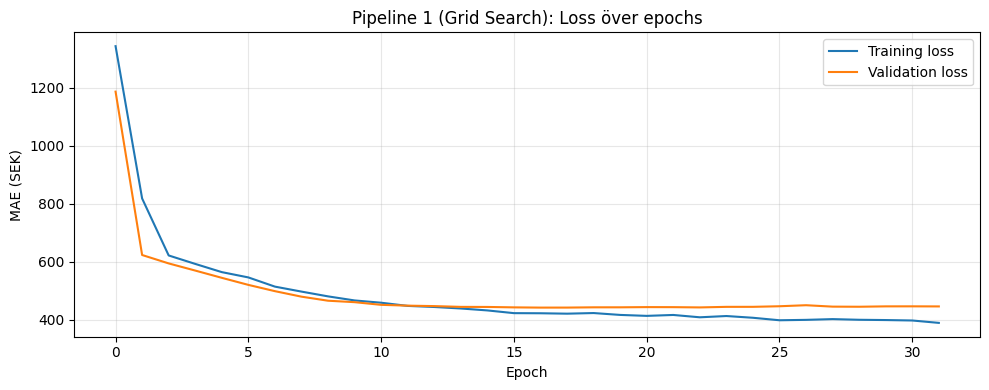

In [4]:
# Kan vi förbättra resultatet med Grid search och early stop?

# ============================================================
# KERAS TUNER GRID SEARCH — Pipeline 1 (bara text)
# Följer kursens struktur från sid 18-20
# ============================================================

import keras_tuner as kt
import tensorflow as tf
import numpy as np
from sklearn.metrics import r2_score

# ============================================================
# STEG 1: Definiera build_model med hyperparametrar
# ============================================================
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(X_train_text.shape[1],)),
        
        # Första dolda lagret
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer1", [128, 256]),
            activation="relu"
        ),
        tf.keras.layers.Dropout(
            hp.Choice("dropout_layer1", [0.3, 0.4])
        ),
        
        # Andra dolda lagret
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer2", [64, 128]),
            activation="relu"
        ),
        tf.keras.layers.Dropout(
            hp.Choice("dropout_layer2", [0.2, 0.3])
        ),
        
        # Tredje dolda lagret (mindre)
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer3", [32, 64]),
            activation="relu"
        ),
        
        # Output: 1 neuron, linjär (regression)
        tf.keras.layers.Dense(1)
    ])
    
    # Optimerare med olika learning rates
    learning_rate = hp.Choice("learning_rate", [0.001, 0.0005])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="mae",
        metrics=["mae"]
    )
    return model


# ============================================================
# STEG 2: Skapa GridSearch Tuner
# ============================================================
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_mae",
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_airbnb",
    project_name="grid_search_pipeline1"
)

# Visa sökrymden
tuner.search_space_summary()


# ============================================================
# STEG 3: Kör grid search med Early Stopping
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

print("\nStartar Grid Search... (tar några minuter)")
print("Early Stopping aktiverat - dåliga försök avbryts tidigt\n")

tuner.search(
    X_train_text, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# STEG 4: Visa bästa hyperparametrar
# ============================================================
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "=" * 60)
print("BÄSTA HYPERPARAMETRAR FUNNA")
print("=" * 60)
print(f"  Neuroner lager 1:        {best_hps.get('n_neurons_layer1')}")
print(f"  Dropout lager 1:         {best_hps.get('dropout_layer1')}")
print(f"  Neuroner lager 2:        {best_hps.get('n_neurons_layer2')}")
print(f"  Dropout lager 2:         {best_hps.get('dropout_layer2')}")
print(f"  Neuroner lager 3:        {best_hps.get('n_neurons_layer3')}")
print(f"  Learning rate:           {best_hps.get('learning_rate')}")


# ============================================================
# STEG 5: Bygg bästa modellen och träna ordentligt
# ============================================================
best_model_text = build_model(best_hps)

print(f"\nBästa modell — antal parametrar: {best_model_text.count_params():,}")

# Mer generös Early Stopping för slutträning
early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

print("\nTränar bästa modellen i upp till 100 epochs...")
history_best_text = best_model_text.fit(
    X_train_text, y_train,
    validation_data=(X_test_text, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_final],
    verbose=1
)


# ============================================================
# STEG 6: Utvärdera med alla mätvärden
# ============================================================
y_pred_best_text = best_model_text.predict(X_test_text).flatten()

mae   = np.mean(np.abs(y_pred_best_text - y_test))
rmse  = np.sqrt(np.mean((y_pred_best_text - y_test) ** 2))
medae = np.median(np.abs(y_test - y_pred_best_text))
mape  = np.mean(np.abs((y_test - y_pred_best_text) / y_test)) * 100
r2    = r2_score(y_test, y_pred_best_text)

print("\n" + "=" * 60)
print("PIPELINE 1 — GRID SEARCH OPTIMERAD")
print("=" * 60)
print(f"Jämförelse:")
print(f"  Original Pipeline 1:   MAE 441.7 SEK, R² 0.447")
print(f"  Grid Search Pipeline 1: MAE {mae:.1f} SEK, R² {r2:.3f}")
print(f"")
print(f"Detaljerat:")
print(f"  MAE:       {mae:>7.1f} SEK")
print(f"  Median AE: {medae:>7.1f} SEK")
print(f"  RMSE:      {rmse:>7.1f} SEK")
print(f"  MAPE:      {mape:>7.1f} %")
print(f"  R²:        {r2:>7.3f}")


# ============================================================
# STEG 7: Plotta loss-kurvan
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history_best_text.history["loss"], label="Training loss")
plt.plot(history_best_text.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Pipeline 1 (Grid Search): Loss över epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Grid search bidrog inte med någon förbättring :( 

In [16]:
# Lite exempel på hur vår ostrukturerade data (fritext) kan se ut!
pd.set_option('display.max_colwidth', None)
print(df[['description', 'name', 'amenities', 'neighborhood_overview', 'host_about', 'price']].sample(15))

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              description  \
4849                                                                                                                                                                                                                                                                                                                                                                                                          Enjoy a cozy experience at this centrally-located place in St

In [5]:
# ============================================================
# PERMUTATION IMPORTANCE — Pipeline 1 (bara text)
# Samma metod som Pipeline 2, men nu ser vi orden klart
# ============================================================

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

# ============================================================
# Wrapper (samma som tidigare)
# ============================================================
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, keras_model):
        self.keras_model = keras_model
    
    def fit(self, X, y):
        pass
    
    def predict(self, X):
        return self.keras_model.predict(X, verbose=0).flatten()

# ============================================================
# Wrappa text-modellen och kör permutation
# ============================================================
wrapped_text = KerasRegressorWrapper(model_text)

print("Kör permutation importance på Pipeline 1 (kan ta några minuter)...")
result_text = permutation_importance(
    wrapped_text, X_test_text, y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42)

# ============================================================
# Sammanställ feature-namn
# ============================================================
# OBS: I Pipeline 1 finns BARA text-features — inga numeriska eller kategoriska
text_feature_names = []
text_field_lookup = {}  # word → vilket textfält

for col in tfidf_settings.keys():
    words = tfidf_vectorizers[col].get_feature_names_out().tolist()
    for w in words:
        text_feature_names.append(w)
        text_field_lookup[(col, w)] = True
    
# För att veta vilket fält varje feature kommer från, bygg en index-baserad lookup
field_per_idx = []
for col in tfidf_settings.keys():
    n = tfidf_vectorizers[col].get_feature_names_out().shape[0]
    field_per_idx.extend([col] * n)

# ============================================================
# Bygg DataFrame
# ============================================================
fi_text = pd.DataFrame({
    "ord":        text_feature_names,
    "textfält":   field_per_idx,
    "importance": result_text.importances_mean,
    "std":        result_text.importances_std,
})

fi_text = fi_text.sort_values("importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("PIPELINE 1 — TOPP 30 VIKTIGASTE ORD")
print("=" * 70)
print(fi_text.head(30).to_string(index=False))

Kör permutation importance på Pipeline 1 (kan ta några minuter)...

PIPELINE 1 — TOPP 30 VIKTIGASTE ORD
        ord              textfält  importance      std
      okänt            host_about   18.738861 3.046970
       room                  name   16.482529 1.989487
      okänt neighborhood_overview    9.273990 2.316747
      villa                  name    8.777219 2.060112
   bedrooms           description    7.509979 1.778159
   children             amenities    6.887363 2.222095
         tv             amenities    6.294778 1.280523
     family           description    6.060635 1.635407
       lock             amenities    5.151236 1.412581
        rum                  name    4.146344 1.390723
  södermalm                  name    3.619962 1.479187
     u2019s             amenities    3.556790 1.330864
      large           description    3.538110 0.905874
 dishwasher             amenities    3.533099 1.418167
      books             amenities    3.410193 0.933893
    bathtub     

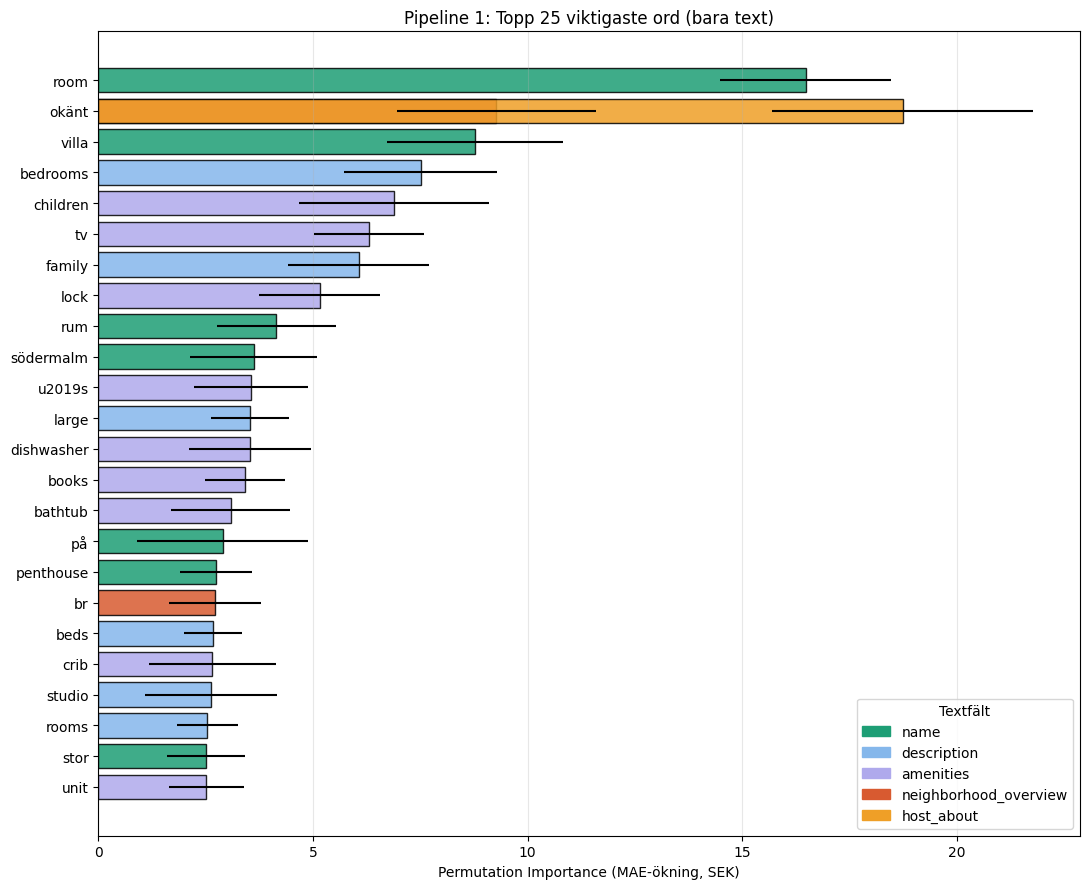

In [6]:
# Färgkoda efter textfält
top_words = fi_text.head(25).iloc[::-1]

color_map_fields = {
    "name":                  "#1D9E75",
    "description":           "#85B7EB",
    "amenities":             "#AFA9EC",
    "neighborhood_overview": "#D85A30",
    "host_about":            "#EF9F27",
}
colors = [color_map_fields[f] for f in top_words["textfält"]]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(top_words["ord"], top_words["importance"],
               xerr=top_words["std"], color=colors, edgecolor="black", alpha=0.85)

ax.set_xlabel("Permutation Importance (MAE-ökning, SEK)")
ax.set_title("Pipeline 1: Topp 25 viktigaste ord (bara text)")
ax.grid(True, alpha=0.3, axis="x")

# Legend
from matplotlib.patches import Patch
legend_items = [Patch(color=c, label=f) for f, c in color_map_fields.items()]
ax.legend(handles=legend_items, loc="lower right", title="Textfält")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Topp 5 ord per textfält — vilka är "guldorden" i varje fält?
# ============================================================
print("\n" + "=" * 60)
print("TOPP 5 ORD PER TEXTFÄLT")
print("=" * 60)

for fält in tfidf_settings.keys():
    sub = fi_text[fi_text["textfält"] == fält].head(5)
    if len(sub) > 0:
        print(f"\n{fält}:")
        for _, row in sub.iterrows():
            print(f"  '{row['ord']}': {row['importance']:.2f} SEK")


TOPP 5 ORD PER TEXTFÄLT

name:
  'room': 17.23 SEK
  'villa': 7.94 SEK
  'rum': 4.31 SEK
  'södermalm': 2.99 SEK
  'penthouse': 2.77 SEK

description:
  'bedrooms': 6.77 SEK
  'family': 5.68 SEK
  'large': 3.55 SEK
  'studio': 2.25 SEK
  'house': 2.21 SEK

amenities:
  'tv': 6.51 SEK
  'children': 5.60 SEK
  'lock': 5.07 SEK
  'crib': 2.98 SEK
  'dishwasher': 2.87 SEK

neighborhood_overview:
  'okänt': 8.06 SEK
  'br': 3.05 SEK
  'local': 2.15 SEK
  'minutes': 0.80 SEK
  'location': 0.63 SEK

host_about:
  'okänt': 15.30 SEK
  'stay': 1.98 SEK
  'experience': 1.71 SEK
  'people': 1.29 SEK
  'city': 1.20 SEK


In [ ]:
"""
Värdet 6.26 SEK för okänt betyder:
Om jag förstör denna feature blir modellen 6.26 SEK sämre.

Det säger inget om dyrt eller billigt.
Permutation importance är som att fråga hur viktig är termometern i bilen? — svaret säger inget om det är varmt eller kallt ute. Bara att informationen är värd att ha.
""

In [7]:
ord_att_testa = [
    ("host_about",            "okänt"),
    ("neighborhood_overview", "okänt"),
    ("name",                  "private"),
    ("amenities",             "lockbox"),
    ("amenities",             "elevator"),
    ("amenities",             "washer"),
    ("description",           "subway"),
    ("description",           "family"),
]

print(f"{'Fält':25s} {'Ord':15s} {'Med':>8s} {'Utan':>8s} {'Diff':>8s}")
print("-" * 70)
for fält, ord in ord_att_testa:
    mask = df[fält].str.lower().str.contains(ord, na=False)
    med  = df.loc[mask, "price"].mean()
    utan = df.loc[~mask, "price"].mean()
    diff = med - utan
    print(f"{fält:25s} {ord:15s} {med:>8.0f} {utan:>8.0f} {diff:>+8.0f}")

Fält                      Ord                  Med     Utan     Diff
----------------------------------------------------------------------
host_about                okänt               1408     1313      +95
neighborhood_overview     okänt               1313     1449     -135
name                      private             1205     1367     -162
amenities                 lockbox             1344     1367      -23
amenities                 elevator            1358     1364       -6
amenities                 washer              1437     1113     +324
description               subway              1317     1376      -59
description               family              1827     1302     +525


In [ ]:
# Utökad pipeline, lägg till numeriska variabler till modellen!

Efter all rensning: 3027 rader kvar
Train: 2421, Test: 606

Bygger TF-IDF-vektorer...
  name                     : 100 features
  description              : 200 features
  amenities                : 100 features
  neighborhood_overview    :  50 features
  host_about               :  50 features

Final feature matrix:
  Train: (2421, 536)
  Numerisk: 32, Kategorisk: 4, Text: 500

Modell — antal parametrar: 79,105
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1231.6349 - mae: 1231.6349 - val_loss: 819.6016 - val_mae: 819.6016
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 680.8782 - mae: 680.8782 - val_loss: 575.7986 - val_mae: 575.7986
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 515.0974 - mae: 515.0974 - val_loss: 457.4028 - val_mae: 457.4028
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 437.7093 - mae: 437.7093 - val_loss: 416.5226 - val_mae: 416.5226
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 409.9341 - mae: 409.934

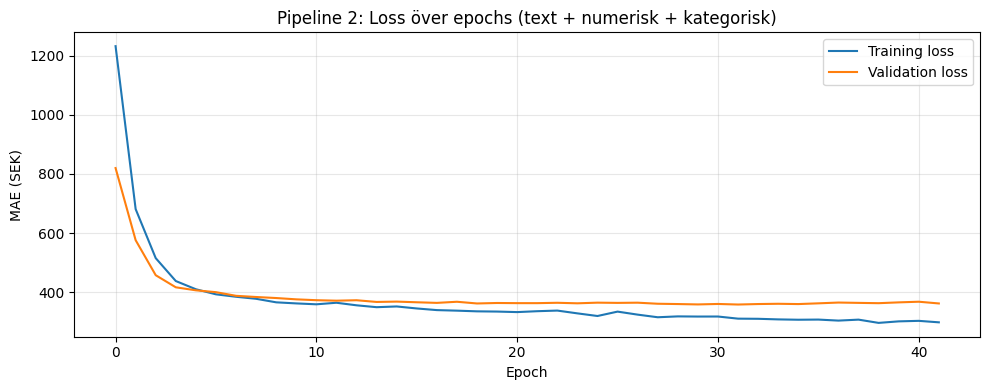

In [4]:
# ============================================================
# PIPELINE 2: TEXT + NUMERISKA + KATEGORISKA
# Återanvänder TF-IDF från Pipeline 1
# Lägger till numeriska och kategoriska features
# ============================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.sparse import hstack, csr_matrix

# ============================================================
# STEG 1: Definiera kolumngrupper
# ============================================================
cat_cols = ["property_type", "room_type",
            "neighbourhood_cleansed", "host_response_time"]

num_cols = [
    "bedrooms", "bathrooms", "beds", "accommodates",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "latitude", "longitude",
    "availability_30", "availability_60",
    "availability_90", "availability_365",
    "host_listings_count", "calculated_host_listings_count",
]

bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "instant_bookable",
             "has_availability"]

# ============================================================
# STEG 2: Procent-strängar och datum
# (df är samma som från Pipeline 1)
# ============================================================
def parse_pct(s):
    return pd.to_numeric(
        s.astype(str).str.rstrip("%").str.strip().replace("", np.nan),
        errors="coerce") / 100

df["host_response_rate"]   = parse_pct(df["host_response_rate"])
df["host_acceptance_rate"] = parse_pct(df["host_acceptance_rate"])
num_cols += ["host_response_rate", "host_acceptance_rate"]

df["host_since"] = pd.to_datetime(df["host_since"], errors="coerce")
df["host_age_days"] = (pd.Timestamp.now() - df["host_since"]).dt.days
num_cols += ["host_age_days"]

# ============================================================
# STEG 3: Booleans → 0/1
# ============================================================
for c in bool_cols:
    df[c] = (df[c].astype(str).str.strip().str.lower() == "t").astype(int)
num_cols += bool_cols

# ============================================================
# STEG 4: Kategoriska → LabelEncode
# ============================================================
encoders = {}
for c in cat_cols:
    df[c] = df[c].fillna("okänt").astype(str)
    le = LabelEncoder()
    df[c + "_enc"] = le.fit_transform(df[c])
    encoders[c] = le

cat_enc_cols = [c + "_enc" for c in cat_cols]

# ============================================================
# STEG 5: Numeriska — tvinga till tal, fyll median
# ============================================================
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

# ============================================================
# STEG 6: Stryp outliers i features
# ============================================================
df = df[df["bedrooms"].between(0, 10)]
df = df[df["bathrooms"].between(0, 10)]
df = df[df["accommodates"].between(1, 20)]
df = df[df["minimum_nights"].between(1, 365)]

print(f"Efter all rensning: {len(df)} rader kvar")

# ============================================================
# STEG 7: Splitta OM (samma random_state = samma split)
# ============================================================
y = df[target].values.astype("float32")

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train_df)}, Test: {len(X_test_df)}")

# ============================================================
# STEG 8: Bygg om TF-IDF (nya rader = nytt vokabulär)
# ============================================================
print("\nBygger TF-IDF-vektorer...")

tfidf_train = []
tfidf_test = []

for col, max_feat in tfidf_settings.items():
    tfidf = TfidfVectorizer(
        max_features=max_feat,
        stop_words="english",
        lowercase=True,
        min_df=5,
        ngram_range=(1, 1))
    
    train_vec = tfidf.fit_transform(X_train_df[col].values)
    test_vec  = tfidf.transform(X_test_df[col].values)
    
    tfidf_train.append(train_vec)
    tfidf_test.append(test_vec)
    print(f"  {col:25s}: {train_vec.shape[1]:>3} features")

# ============================================================
# STEG 9: Skala numeriska
# ============================================================
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_df[num_cols]).astype("float32")
X_test_num  = scaler.transform(X_test_df[num_cols]).astype("float32")

# ============================================================
# STEG 10: Kombinera ALLT till en matris
# ============================================================
X_train_num_sp = csr_matrix(X_train_num)
X_test_num_sp  = csr_matrix(X_test_num)

X_train_cat_sp = csr_matrix(X_train_df[cat_enc_cols].values.astype("float32"))
X_test_cat_sp  = csr_matrix(X_test_df[cat_enc_cols].values.astype("float32"))

X_train_full = hstack([X_train_num_sp, X_train_cat_sp] + tfidf_train).toarray().astype("float32")
X_test_full  = hstack([X_test_num_sp,  X_test_cat_sp]  + tfidf_test).toarray().astype("float32")

print(f"\nFinal feature matrix:")
print(f"  Train: {X_train_full.shape}")
print(f"  Numerisk: {len(num_cols)}, Kategorisk: {len(cat_enc_cols)}, Text: {sum(t.shape[1] for t in tfidf_train)}")

# ============================================================
# STEG 11: Bygg samma Sequential modell
# ============================================================
model_full = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_full.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_full.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"])

print(f"\nModell — antal parametrar: {model_full.count_params():,}")

# ============================================================
# STEG 12: Träna
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True)

history_full = model_full.fit(
    X_train_full, y_train,
    validation_data=(X_test_full, y_test),
    epochs=100, batch_size=32,
    callbacks=[early_stop],
    verbose=1)

# ============================================================
# STEG 13: Utvärdera Pipeline 2 (alla mätvärden direkt)
# ============================================================
y_pred_full = model_full.predict(X_test_full).flatten()

mae_full   = np.mean(np.abs(y_pred_full - y_test))
rmse_full  = np.sqrt(np.mean((y_pred_full - y_test) ** 2))
medae_full = np.median(np.abs(y_test - y_pred_full))
mape_full  = np.mean(np.abs((y_test - y_pred_full) / y_test)) * 100
r2_full    = r2_score(y_test, y_pred_full)

mean_pred = y_train.mean()
mae_base = np.mean(np.abs(y_test - mean_pred))

print("\n" + "=" * 50)
print("PIPELINE 2 — ALLT TILLSAMMANS")
print("=" * 50)
print(f"Antal features:        {X_train_full.shape[1]}")
print(f"  varav numeriska:     {len(num_cols)}")
print(f"  varav kategoriska:   {len(cat_enc_cols)}")
print(f"  varav text (TF-IDF): {sum(t.shape[1] for t in tfidf_train)}")
print(f"")
print(f"MAE 'gissa medel':     {mae_base:.1f} SEK")
print(f"MAE pipeline 1 (text): 441.7 SEK")
print(f"MAE pipeline 2 (allt): {mae_full:.1f} SEK")
print(f"RMSE:                  {rmse_full:.1f} SEK")
print(f"Median AE:             {medae_full:.1f} SEK")
print(f"MAPE:                  {mape_full:.1f} %")
print(f"R²:                    {r2_full:.3f}")
print(f"Relativt fel:          {mae_full/y_test.mean()*100:.1f}%")

# ============================================================
# STEG 14: Plotta loss
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(history_full.history["loss"], label="Training loss")
plt.plot(history_full.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Pipeline 2: Loss över epochs (text + numerisk + kategorisk)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# PERMUTATION IMPORTANCE — Pipeline 2 (allt)
# Använder exakt samma teknik som kursen (KerasModelWrapper)
# Modifierad för regression istället för klassificering
# ============================================================

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

# ============================================================
# Wrapper-klass (samma struktur som kursen, men för regression)
# ============================================================
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    # I kursen var det ClassifierMixin — för regression använder vi RegressorMixin
    
    def __init__(self, keras_model):
        self.keras_model = keras_model
    
    def fit(self, X, y):
        # Modellen är redan tränad
        pass
    
    def predict(self, X):
        # Returnera kontinuerligt värde direkt (ingen argmax)
        return self.keras_model.predict(X, verbose=0).flatten()

# ============================================================
# Sätt upp permutation importance
# ============================================================
wrapped_model = KerasRegressorWrapper(model_full)

print("Kör permutation importance (kan ta några minuter)...")
result = permutation_importance(
    wrapped_model, X_test_full, y_test,
    scoring="neg_mean_absolute_error",   # för regression
    n_repeats=10,
    random_state=42)

# ============================================================
# Sammanställ feature-namn (samma ordning som i matrisen)
# ============================================================
# Ordning i X_train_full: [numeric, cat, tfidf...]
feature_names = (
    num_cols +                                    # 32 numeriska
    cat_enc_cols +                                # 4 kategoriska
    list(tfidf_vectorizers["name"].get_feature_names_out()) +
    list(tfidf_vectorizers["description"].get_feature_names_out()) +
    list(tfidf_vectorizers["amenities"].get_feature_names_out()) +
    list(tfidf_vectorizers["neighborhood_overview"].get_feature_names_out()) +
    list(tfidf_vectorizers["host_about"].get_feature_names_out())
)

# Prefixa text-features för att göra dem distinkta
text_field_offsets = []
offset = len(num_cols) + len(cat_enc_cols)
for col in tfidf_settings.keys():
    n_features = tfidf_vectorizers[col].get_feature_names_out().shape[0]
    text_field_offsets.append((col, offset, offset + n_features))
    offset += n_features

# Skapa kategori-etikett per feature
def get_category(idx):
    if idx < len(num_cols):
        return "Numerisk"
    elif idx < len(num_cols) + len(cat_enc_cols):
        return "Kategorisk"
    else:
        for col, start, end in text_field_offsets:
            if start <= idx < end:
                return f"Text ({col})"
    return "Okänd"

# ============================================================
# Bygg DataFrame
# ============================================================
fi_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": result.importances_mean,
    "std":        result.importances_std,
    "kategori":   [get_category(i) for i in range(len(feature_names))],
})

# Sortera efter importance (störst först)
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("TOPP 20 FEATURES")
print("=" * 60)
print(fi_df.head(20).to_string(index=False))

Kör permutation importance (kan ta några minuter)...

TOPP 20 FEATURES
                       feature  importance      std                     kategori
                      bedrooms   63.547632 6.014441                     Numerisk
                  accommodates   61.235492 5.862917                     Numerisk
                     longitude   38.115356 4.201665                     Numerisk
                 room_type_enc   31.815570 6.829297                   Kategorisk
                minimum_nights   20.437360 2.981445                     Numerisk
                      latitude   17.977481 3.574597                     Numerisk
        review_scores_location   12.521716 2.695811                     Numerisk
           review_scores_value   12.301004 2.387190                     Numerisk
                           och   12.286807 2.376247            Text (host_about)
               availability_30   11.005249 2.376979                     Numerisk
             reviews_per_month    9.26

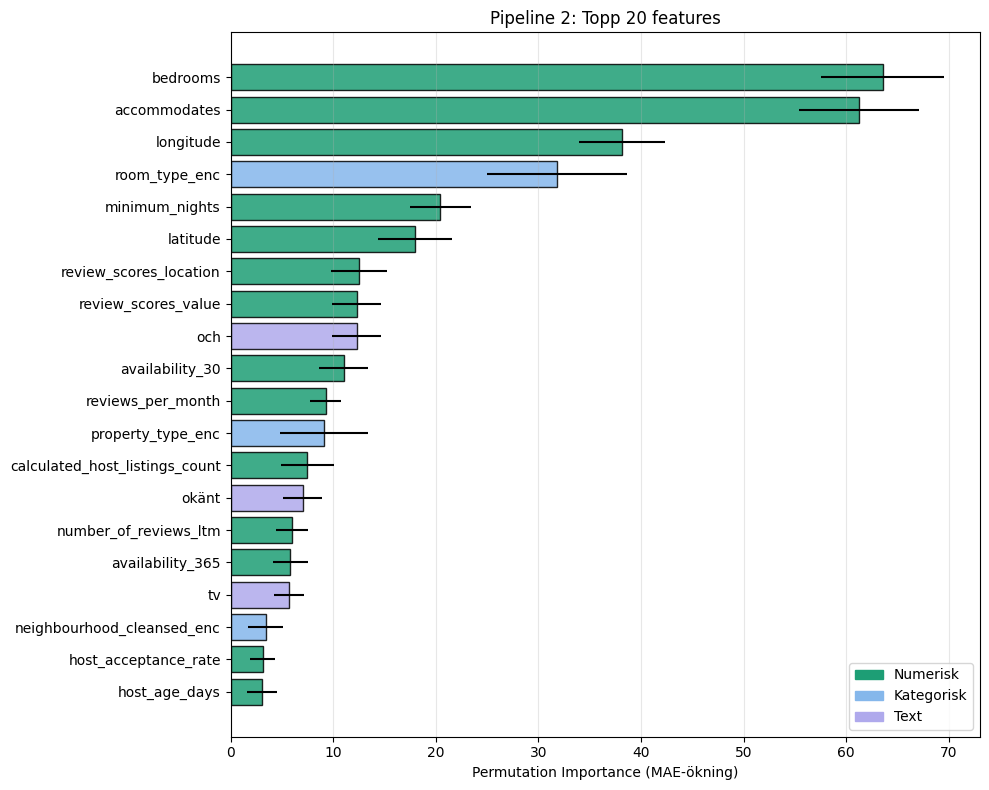

In [10]:
# Topp 20
top = fi_df.head(20).iloc[::-1]  # vänd för plot

# Färgkoda efter kategori
def short_cat(c):
    if c.startswith("Text"): return "Text"
    return c

top["short_kat"] = top["kategori"].apply(short_cat)

color_map = {"Numerisk": "#1D9E75", "Kategorisk": "#85B7EB", "Text": "#AFA9EC"}
colors = [color_map[c] for c in top["short_kat"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top["feature"], top["importance"],
               xerr=top["std"], color=colors, edgecolor="black", alpha=0.85)

ax.set_xlabel("Permutation Importance (MAE-ökning)")
ax.set_title("Pipeline 2: Topp 20 features")
ax.grid(True, alpha=0.3, axis="x")

# Legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=t) for t, c in color_map.items()]
ax.legend(handles=legend, loc="lower right")

plt.tight_layout()
plt.show()

In [5]:
# Summera per kategori
fi_df["kategori_grov"] = fi_df["kategori"].apply(short_cat)
summary = fi_df.groupby("kategori_grov")["importance"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

print("\n" + "=" * 50)
print("SUMMERAT PER KATEGORI")
print("=" * 50)
print(summary)

# Andel av total importance
total = fi_df["importance"].sum()
summary["andel_%"] = (summary["sum"] / total * 100).round(1)
print(f"\nAndel av total importance:")
print(summary[["sum", "andel_%"]])

NameError: name 'fi_df' is not defined

Trial 64 Complete [00h 00m 17s]
val_mae: 344.68927001953125

Best val_mae So Far: 339.5824890136719
Total elapsed time: 00h 14m 26s

BÄSTA HYPERPARAMETRAR FUNNA
  Neuroner lager 1:        256
  Dropout lager 1:         0.3
  Neuroner lager 2:        64
  Dropout lager 2:         0.3
  Neuroner lager 3:        32
  Learning rate:           0.001

Bästa modell — antal parametrar: 156,033

Tränar bästa modellen i upp till 100 epochs...
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1146.0876 - mae: 1146.0876 - val_loss: 716.5878 - val_mae: 716.5878
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 617.1589 - mae: 617.1589 - val_loss: 497.0907 - val_mae: 497.0907
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 454.8893 - mae: 454.8893 - val_loss: 429.1350 - val_mae: 429.1350
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 408.4223 - mae: 408.4223 - val_loss: 404.5052 - val_mae: 404.5052
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38

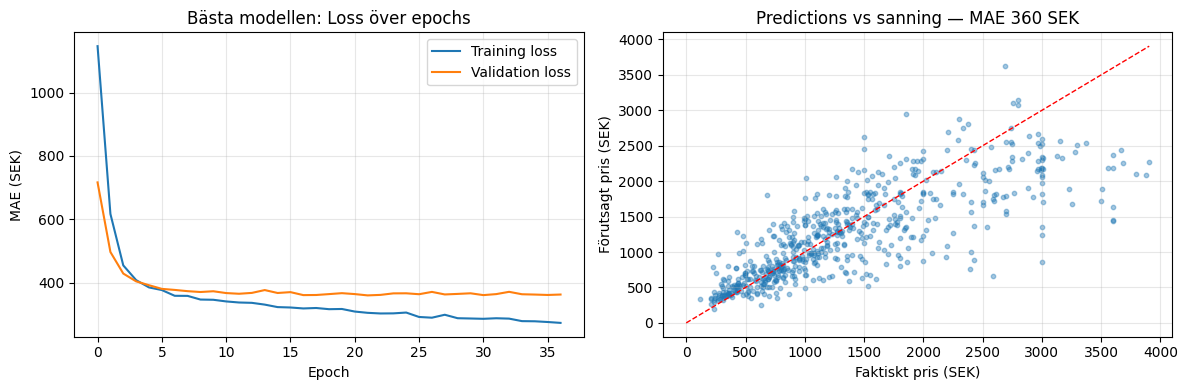

In [6]:
# Kan vi ytterligare förbättra resultatet med Grid Search?

# ============================================================
# KERAS TUNER GRID SEARCH — Pipeline 2
# Hittar bästa hyperparametrarna för vår modell
# Följer kursens struktur från sid 18-20
# ============================================================

import keras_tuner as kt
import tensorflow as tf
import numpy as np
from sklearn.metrics import r2_score

# ============================================================
# STEG 1: Definiera build_model med hyperparametrar
# (Reducerad sökrymd: 64 kombinationer istället för 2 916)
# ============================================================
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(X_train_full.shape[1],)),
        
        # Första dolda lagret
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer1", [128, 256]),
            activation="relu"
        ),
        tf.keras.layers.Dropout(
            hp.Choice("dropout_rate_layer1", [0.3, 0.4])
        ),
        
        # Andra dolda lagret
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer2", [64, 128]),
            activation="relu"
        ),
        tf.keras.layers.Dropout(
            hp.Choice("dropout_rate_layer2", [0.2, 0.3])
        ),
        
        # Tredje dolda lagret (mindre)
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer3", [32, 64]),
            activation="relu"
        ),
        
        # Output: 1 neuron, linjär (regression)
        tf.keras.layers.Dense(1)
    ])
    
    # Optimerare med olika learning rates
    learning_rate = hp.Choice("learning_rate", [0.001, 0.0005])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="mae",
        metrics=["mae"]
    )
    return model

# ============================================================
# STEG 2: Skapa GridSearch Tuner
# ============================================================
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_mae",            # vi minimerar val_mae för regression
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_airbnb",
    project_name="grid_search_pipeline2"
)

# Visa sökrymden
tuner.search_space_summary()

# ============================================================
# STEG 3: Kör grid search
# 64 kombinationer × upp till 100 epochs (med Early Stopping)
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

print("\nStartar Grid Search... (tar några minuter)")
tuner.search(
    X_train_full, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# STEG 4: Hämta bästa hyperparametrarna
# ============================================================
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "=" * 60)
print("BÄSTA HYPERPARAMETRAR FUNNA")
print("=" * 60)
print(f"  Neuroner lager 1:        {best_hps.get('n_neurons_layer1')}")
print(f"  Dropout lager 1:         {best_hps.get('dropout_rate_layer1')}")
print(f"  Neuroner lager 2:        {best_hps.get('n_neurons_layer2')}")
print(f"  Dropout lager 2:         {best_hps.get('dropout_rate_layer2')}")
print(f"  Neuroner lager 3:        {best_hps.get('n_neurons_layer3')}")
print(f"  Learning rate:           {best_hps.get('learning_rate')}")

# ============================================================
# STEG 5: Bygg den bästa modellen och träna ordentligt
# ============================================================
best_model = build_model(best_hps)

print(f"\nBästa modell — antal parametrar: {best_model.count_params():,}")

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

print("\nTränar bästa modellen i upp till 100 epochs...")
history_best = best_model.fit(
    X_train_full, y_train,
    validation_data=(X_test_full, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_final],
    verbose=1
)

# ============================================================
# STEG 6: Utvärdera bästa modellen med alla mätvärden
# ============================================================
y_pred_best = best_model.predict(X_test_full).flatten()

mae_best   = np.mean(np.abs(y_pred_best - y_test))
rmse_best  = np.sqrt(np.mean((y_pred_best - y_test) ** 2))
medae_best = np.median(np.abs(y_test - y_pred_best))
mape_best  = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100
r2_best    = r2_score(y_test, y_pred_best)

mean_pred = y_train.mean()
mae_base = np.mean(np.abs(y_test - mean_pred))

print("\n" + "=" * 60)
print("PIPELINE 2 — GRID SEARCH OPTIMERAD")
print("=" * 60)
print(f"Jämförelse:")
print(f"  MAE 'gissa medel':       {mae_base:.1f} SEK")
print(f"  MAE pipeline 1 (text):   441.7 SEK    R² 0.447")
print(f"  MAE pipeline 2 (allt):   361.7 SEK    R² 0.613")
print(f"  MAE Grid Search:         {mae_best:.1f} SEK    R² {r2_best:.3f}   ← ny")
print(f"")
print(f"Detaljerat:")
print(f"  MAE:       {mae_best:>7.1f} SEK")
print(f"  Median AE: {medae_best:>7.1f} SEK")
print(f"  RMSE:      {rmse_best:>7.1f} SEK")
print(f"  MAPE:      {mape_best:>7.1f} %")
print(f"  R²:        {r2_best:>7.3f}")
print(f"  Relativt fel: {mae_best/y_test.mean()*100:.1f}%")

# ============================================================
# STEG 7: Spara bästa modellen
# ============================================================
#best_model.save("best_airbnb_model.h5")
#print("\nBästa modellen sparad som best_airbnb_model.h5")

# ============================================================
# STEG 8: Plotta loss-kurvan
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_best.history["loss"], label="Training loss")
plt.plot(history_best.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Bästa modellen: Loss över epochs")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_best, alpha=0.4, s=10)
mx = max(y_test.max(), y_pred_best.max())
plt.plot([0, mx], [0, mx], "r--", linewidth=1)
plt.xlabel("Faktiskt pris (SEK)")
plt.ylabel("Förutsagt pris (SEK)")
plt.title(f"Predictions vs sanning — MAE {mae_best:.0f} SEK")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Grid search gav i princip ingen förbättring för pipe 2 heller. Det är tydligt att vår ursprungliga arkitektur var nära optimum.

In [ ]:
# PRISESTIMATOR! Mata in värden och få en prediktion!

# Först en med alla variabler, omständigare att fylla i, men säkrare prediktion.
# Efteråt kommer en variant med bara fritext-variablerna som är behändigare att populera.

In [7]:
# ============================================================
# PRISESTIMATOR
# Mata in en bostads-beskrivning → få pris
# ============================================================

def estimate_price(listing_dict, model=best_model):
    """
    Estimera pris för en AirBnB-listing.
    
    listing_dict: dict med textfält, kategoriska fält, och numeriska fält
    """
    import pandas as pd
    from scipy.sparse import hstack, csr_matrix
    
    # Steg 1: Gör om input till en DataFrame med 1 rad
    sample_df = pd.DataFrame([listing_dict])
    
    # Steg 2: TF-IDF på textfält (transform, inte fit!)
    text_vecs = []
    for col in tfidf_settings.keys():
        text = sample_df.get(col, pd.Series(["okänt"])).fillna("okänt").astype(str)
        text_vec = tfidf_vectorizers[col].transform(text)
        text_vecs.append(text_vec)
    
    # Steg 3: Kategoriska — använd samma encoder som tidigare
    cat_values = []
    for col in cat_cols:
        val = sample_df.get(col, pd.Series(["okänt"])).iloc[0]
        # Om värdet inte finns i encoder: fall tillbaka på 'okänt' eller 0
        if val in encoders[col].classes_:
            enc = encoders[col].transform([val])[0]
        else:
            enc = 0  # default
        cat_values.append(enc)
    
    # Steg 4: Numeriska — fyll saknade med median från träning
    num_values = []
    for col in num_cols:
        if col in sample_df.columns and pd.notna(sample_df[col].iloc[0]):
            num_values.append(float(sample_df[col].iloc[0]))
        else:
            num_values.append(df[col].median())  # default = träningsmedian
    
    # Steg 5: Skala numeriska med samma scaler
    import numpy as np
    num_array = np.array(num_values).reshape(1, -1)
    num_scaled = scaler.transform(num_array).astype("float32")
    
    # Steg 6: Kombinera till en feature-vektor
    num_sp = csr_matrix(num_scaled)
    cat_sp = csr_matrix(np.array(cat_values).reshape(1, -1).astype("float32"))
    
    X_sample = hstack([num_sp, cat_sp] + text_vecs).toarray().astype("float32")
    
    # Steg 7: Förutsäg
    predicted_price = model.predict(X_sample, verbose=0).flatten()[0]
    
    return predicted_price


# ============================================================
# EXEMPEL 1: En enkel lägenhet på Södermalm
# ============================================================
listing_1 = {
    "name":                  "Cozy studio in Södermalm",
    "description":           "Charming small apartment, 5 minutes walk to subway. Perfect for solo travelers or couples.",
    "amenities":             "wifi, kitchen, washer, heating",
    "neighborhood_overview": "Södermalm is a trendy area with great restaurants and shops.",
    "host_about":            "I love hosting travelers from around the world!",
    
    "property_type":         "Entire rental unit",
    "room_type":             "Entire home/apt",
    "neighbourhood_cleansed": "Södermalms",
    "host_response_time":    "within an hour",
    
    "bedrooms":              1,
    "bathrooms":             1,
    "beds":                  1,
    "accommodates":          2,
    "minimum_nights":        2,
    "maximum_nights":        90,
    "number_of_reviews":     45,
    "number_of_reviews_ltm": 15,
    "reviews_per_month":     2.5,
    "review_scores_rating":  4.8,
    "latitude":              59.3151,
    "longitude":             18.0758,
    "availability_30":       15,
}

price_1 = estimate_price(listing_1)
print(f"Exempel 1 (studio Södermalm):  {price_1:.0f} SEK/natt")


# ============================================================
# EXEMPEL 2: En större lägenhet i Östermalm
# ============================================================
listing_2 = {
    "name":                  "Luxury 3-bedroom apartment in Östermalm",
    "description":           "Spacious renovated apartment with high ceilings and balcony. Family-friendly. 2 minutes to subway.",
    "amenities":             "wifi, kitchen, washer, dryer, dishwasher, elevator, tv, parking",
    "neighborhood_overview": "Östermalm is one of Stockholm's most exclusive neighborhoods.",
    "host_about":            "Welcome! I host with care and attention to detail.",
    
    "property_type":         "Entire rental unit",
    "room_type":             "Entire home/apt",
    "neighbourhood_cleansed": "Östermalms",
    "host_response_time":    "within an hour",
    
    "bedrooms":              3,
    "bathrooms":             2,
    "beds":                  4,
    "accommodates":          6,
    "minimum_nights":        3,
    "maximum_nights":        180,
    "number_of_reviews":     80,
    "number_of_reviews_ltm": 25,
    "reviews_per_month":     3.5,
    "review_scores_rating":  4.9,
    "latitude":              59.3367,
    "longitude":             18.0857,
    "availability_30":       8,
}

price_2 = estimate_price(listing_2)
print(f"Exempel 2 (lyxlägenhet Östermalm): {price_2:.0f} SEK/natt")


# ============================================================
# EXEMPEL 3: Ett privat rum i ytterstaden
# ============================================================
listing_3 = {
    "name":                  "Private room near subway",
    "description":           "Simple room in shared apartment. Good for budget travelers.",
    "amenities":             "wifi, shared kitchen, lockbox",
    "neighborhood_overview": "okänt",
    "host_about":            "okänt",
    
    "property_type":         "Private room in rental unit",
    "room_type":             "Private room",
    "neighbourhood_cleansed": "Vällingby",
    "host_response_time":    "within a few hours",
    
    "bedrooms":              1,
    "bathrooms":             1,
    "beds":                  1,
    "accommodates":          1,
    "minimum_nights":        1,
    "maximum_nights":        30,
    "number_of_reviews":     10,
    "number_of_reviews_ltm": 3,
    "reviews_per_month":     0.8,
    "review_scores_rating":  4.5,
    "latitude":              59.3650,
    "longitude":             17.8730,
    "availability_30":       25,
}

price_3 = estimate_price(listing_3)
print(f"Exempel 3 (privat rum Vällingby): {price_3:.0f} SEK/natt")


# ============================================================
# Exemplet från cellen nedanför med adderade numeriska variabler
# ============================================================
listing_4 = {
    "name": "Elegant & light 3 room apartment in SoFo, 97sqm",
    "description": "The apartment is on the 2nd floor in a beautiful building from 1880 situated in the heart of the trendy area called SoFo at Södermalm. It is a large, light, airy and very stylish 3 room apartment with all the rooms facing a wonderful park giving you a nice view to look at and great privacy. The apartment can easily and very comfortably host 4 guests. The area is one of the popular places in Stockholm with a great variaty of restaurants, bars, cafees and shops.The apartment is newly renovated and is painted in white and light yellow and is furnished in a modern style. The celings are high and windows large and one of the bedrooms have a double bed and the other bedroom has two single beds that could easily be made into one double bed. You have a nice living room with a lot of space and a smart TV with Internet/Netflix and Cable TV. You have access to the whole apartment. The apartment is on 2nd floor and the building has no elevator. If you would like to book the garage parking (only one) you need to eserv it when you make the booking. If it is available there is an extra cost of 200kr per night.",
    "amenities":   "Hair dryer, Shampoo, Hot water, Bedroom and laundry, Washer – In building, Dryer – In building, Towels, bed sheets, soap, and toilet paper, Hangers, Bed linens, Extra pillows and blankets, Room-darkening shades, Iron, Entertainment, Ethernet connection, TV with standard cable, Family, Crib, Pack n play/Travel crib, Baby monitor, Window guards, Babysitter recommendations, Heating and cooling, Indoor fireplace, Heating",
    "neighborhood_overview": "Hornsgatan Hotel is located next to Mariatorget in Södermalm.. The area is well-known for its restaurants, cafes and shops. Walking distance to the Old Town.",
    "host_about":  "We are a family company offering a number of personally designed apartments to people visiting Stockholm for shorter och longer periods. We will do our out most to meet your expectations and give you a memorable stay in the houses and area where our family have lived and worked for almost 150 years.",
    
    "property_type":         "Entire rental unit",
    "room_type":             "Entire home/apt",
    "neighbourhood_cleansed": "Södermalms",
    "host_response_time":    "within an hour",


    
    "bedrooms":              2,
    "bathrooms":             1,
    "beds":                  4,
    "accommodates":          4,
    "minimum_nights":        1,
    "maximum_nights":        30,
    "number_of_reviews":     329,
    "number_of_reviews_ltm": 3,
    "reviews_per_month":     0.8,
    "review_scores_rating":  4.82,
    "latitude":              59.3299,
    "longitude":             18.0430,
    "availability_30":       25,
}

price_4 = estimate_price(listing_4)
print(f"Exempel 4 (Elegant & light 3 room apartment in SoFo, 97sqm): {price_4:.0f} SEK/natt")

# ============================================================
# Exempel2 från cellen nedanför med adderade numeriska variabler. Verkligt pris 377 SEK
# ============================================================
listing_5 = {
    "name": "Room in Sollentuna, Sweden",
    "description": "18 mins on direct train to/from Arlanda airport & 14 mins direct (same train) into central Stockholm. 5 mins walk from train station/ Sollentunas mall. Large room with desk. There is kitchen access but this is limited due to my wife's home baking business, guests may cook more simple foods (e.g. boiling water for pasta, warming something in the microwave). We are a friendly/lively family with a young son. I am English and my wife is Bolivian. Swedish, english and spanish are spoken at home",
    "amenities":   "Lock on bedroom door, Kitchen, Wifi, Washer, Dryer, Hair dryer, Refrigerator",
    "neighborhood_overview": "Sollentuna is a really nice part of Stockholm. Lots of big villas, nice walks down by the lake, where there si also a beach and bbq area. The mall in Sollentuna (5 mins away) is big and well presented. Plenty of Restaurants/cafes around the centre - like O'learys and Texas Longhorn. Our favourites are Garden (in the mall) the chinese just outside the mall and the Columbian restaurant 2 mins from where we live. There is a LIDL (cheap supermarket) 2 minutes walk away and we are only a couple of stops away on the train line from Friends Arena (for concerts and football) and Mall of Scandinavia for shopping",
    "host_about":  "okänt",
    
    "property_type":         "Room in a rental unit",
    "room_type":             "Private room",
    "neighbourhood_cleansed": "Sollentuna",
    "host_response_time":    "within a few hours",


    
    "bedrooms":              1,
    "bathrooms":             0,
    "beds":                  1,
    "accommodates":          2,
    "minimum_nights":        1,
    "maximum_nights":        30,
    "number_of_reviews":     143,
    "number_of_reviews_ltm": 3,
    "reviews_per_month":     0.8,
    "review_scores_rating":  4.86,
    "latitude":              59.4283,
    "longitude":             17.9380,
    "availability_30":       25,
}

price_5 = estimate_price(listing_5)
print(f"Exempel 5 (Room in Sollentuna, Sweden): {price_5:.0f} SEK/natt")

C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Exempel 1 (studio Södermalm):  869 SEK/natt
Exempel 2 (lyxlägenhet Östermalm): 1373 SEK/natt
Exempel 3 (privat rum Vällingby): 198 SEK/natt
Exempel 4 (Elegant & light 3 room apartment in SoFo, 97sqm): 1734 SEK/natt
Exempel 5 (Room in Sollentuna, Sweden): 486 SEK/natt


C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
# Version 2, endast textvariabler. Enklare att fylla i manuellt men tappar en del prestanda såklart

# ============================================================
# PRISESTIMATOR — endast textfält
# Mata in 5 textfält → få ett prisestimat
# ============================================================

def estimate_price_text(listing_dict, model=model_text):
    """
    Estimera pris baserat på endast textfält.
    
    listing_dict kan innehålla:
        name, description, amenities, 
        neighborhood_overview, host_about
    
    Saknade fält fylls automatiskt med "okänt".
    """
    import pandas as pd
    from scipy.sparse import hstack
    
    # Steg 1: Bygg en rad med alla textfält
    sample = {}
    for col in tfidf_settings.keys():
        sample[col] = listing_dict.get(col, "okänt") or "okänt"
    sample_df = pd.DataFrame([sample])
    
    # Steg 2: TF-IDF på varje fält
    text_vecs = []
    for col in tfidf_settings.keys():
        vec = tfidf_vectorizers[col].transform(sample_df[col].astype(str))
        text_vecs.append(vec)
    
    # Steg 3: Kombinera
    X_sample = hstack(text_vecs).toarray().astype("float32")
    
    # Steg 4: Förutsäg
    return model.predict(X_sample, verbose=0).flatten()[0]


# ============================================================
# EXEMPEL — leka med olika beskrivningar
# ============================================================

# Exempel 1: Minimal info
listing_a = {
    "name": "Apartment",
}
price_a = estimate_price_text(listing_a)
print(f"Bara namn ('Apartment'):  {price_a:.0f} SEK/natt")


# Exempel 2: Budget-rum
listing_b = {
    "name":        "Private room near subway",
    "description": "Simple room, good for budget travelers. Self check-in with lockbox.",
    "amenities":   "wifi, shared kitchen, lockbox",
}
price_b = estimate_price_text(listing_b)
print(f"Budget privat rum:         {price_b:.0f} SEK/natt")


# Exempel 3: Familjelägenhet
listing_c = {
    "name":        "Spacious family apartment in Södermalm",
    "description": "Beautiful 3-bedroom apartment, perfect for families. 5 minutes to subway. Recently renovated.",
    "amenities":   "wifi, kitchen, washer, dryer, tv, elevator, dishwasher",
    "neighborhood_overview": "Södermalm is a great area for families with parks and good restaurants.",
    "host_about":  "We are a Swedish family who love welcoming guests to our beautiful city.",
}
price_c = estimate_price_text(listing_c)
print(f"Familjelägenhet Södermalm: {price_c:.0f} SEK/natt")


# Exempel 4: Lyxlägenhet
listing_d = {
    "name":        "Luxury 4-bedroom penthouse Östermalm",
    "description": "Stunning penthouse with balcony and city view. Premium location 2 minutes to subway. Family-friendly with all modern amenities.",
    "amenities":   "wifi, kitchen, washer, dryer, tv, elevator, dishwasher, parking, balcony",
    "neighborhood_overview": "Östermalm is Stockholm's most exclusive neighborhood with high-end shopping and dining.",
    "host_about":  "I am a passionate host with years of experience welcoming international travelers.",
}
price_d = estimate_price_text(listing_d)
print(f"Lyx penthouse Östermalm:   {price_d:.0f} SEK/natt")


# Exempel 5: Custom - https://www.airbnb.com/rooms/40459780?adults=1&check_in=2026-06-27&search_mode=regular_search&source_impression_id=p3_1779776622_P3O76-HBEEiIdlwJ&previous_page_section_name=1000&federated_search_id=89ba3525-7d93-4765-8b00-d71f57774e61&guests=1&check_out=2026-06-28
listing_d = {
    "name": "Cosy single room with private bathroom",
    "description": "We offer a peaceful accommodation with a family atmosphere and personal attention. The staff at the hotel have great knowledge of Stockholm and will gladly give you tips on restaurants, museums and attractions. Hotel Hornsgatan is located on the first floor of a residential building from 1905. Our 22 rooms are individually decorated with views towards Hornsgatan, quiet courtyard or back alley. Of our 22 rooms, nine rooms have private bathrooms, the remaining 13 rooms share five bathrooms located in the corridor. All bathrooms have a shower, sink and toilet. The price of a room includes a breakfast buffet. We offer several kinds of yogurt and cereal, assorted breads with toppings, eggs, fruit and juice, coffee and tea. We have options to suit vegetarians, vegans, gluten and lactose intolerant. Let us know in advance if you require a special diet. Our breakfast room located on the first floor is available 24/7. Here you can help yourself to free coffee, tea, juice, fruit and biscuits any time. For the rooms located on the ground floor, across the court yard there is a fully equipped kitchen availble. This kitchen area is shared between five rooms and equipped with fridge, freezer, stove and owen. We offer a peaceful accommodation with a family atmosphere and personal attention. We at the hotel have great knowledge of Stockholm and will gladly give you tips on restaurants, museums and attractions. Hotel Hornsgatan is located on the first floor of a residential building from 1905. Our 17 rooms are individually decorated with views towards Hornsgatan, quiet courtyard or back street. Of our 17 rooms, four rooms have private bathrooms, the remaining 13 rooms share five bathrooms located in the corridor. In all bathrooms there is a shower, sink and toilet. Located on the ground floor, across the court yard we have five budget rooms that all have a smaller private bathroom.",
    "amenities":   "Hair dryer, Shampoo, Bedroom and laundry, Hangers, Iron, Entertainment, TV, Family Crib, Heating and cooling, Heating, Home safety, Exterior security, cameras on property CCTV camera placed in the reception, Smoke alarm, Wifi, Dedicated workspace, Kitchen and dining, Dishes and silverware, Bowls, chopsticks, plates, cups, Breakfast",
    "neighborhood_overview": "Hornsgatan Hotel is located next to Mariatorget in Södermalm.. The area is well-known for its restaurants, cafes and shops. Walking distance to the Old Town.",
    "host_about":  "okänt",
}
price_d = estimate_price_text(listing_d)
print(f"Eget exempel 1:   {price_d:.0f} SEK/natt")


# Exempel 6: Custom - https://www.airbnb.com/rooms/36925986?adults=1&check_in=2026-06-16&check_out=2026-06-17&search_mode=regular_search&source_impression_id=p3_1779776622_P3FT3jaL1NuAk32B&previous_page_section_name=1000&federated_search_id=89ba3525-7d93-4765-8b00-d71f57774e61
listing_d = {
    "name": "Elegant & light 3 room apartment in SoFo, 97sqm",
    "description": "The apartment is on the 2nd floor in a beautiful building from 1880 situated in the heart of the trendy area called SoFo at Södermalm. It is a large, light, airy and very stylish 3 room apartment with all the rooms facing a wonderful park giving you a nice view to look at and great privacy. The apartment can easily and very comfortably host 4 guests. The area is one of the popular places in Stockholm with a great variaty of restaurants, bars, cafees and shops.The apartment is newly renovated and is painted in white and light yellow and is furnished in a modern style. The celings are high and windows large and one of the bedrooms have a double bed and the other bedroom has two single beds that could easily be made into one double bed. You have a nice living room with a lot of space and a smart TV with Internet/Netflix and Cable TV. You have access to the whole apartment. The apartment is on 2nd floor and the building has no elevator. If you would like to book the garage parking (only one) you need to eserv it when you make the booking. If it is available there is an extra cost of 200kr per night.",
    "amenities":   "Hair dryer, Shampoo, Hot water, Bedroom and laundry, Washer – In building, Dryer – In building, Towels, bed sheets, soap, and toilet paper, Hangers, Bed linens, Extra pillows and blankets, Room-darkening shades, Iron, Entertainment, Ethernet connection, TV with standard cable, Family, Crib, Pack n play/Travel crib, Baby monitor, Window guards, Babysitter recommendations, Heating and cooling, Indoor fireplace, Heating",
    "neighborhood_overview": "Hornsgatan Hotel is located next to Mariatorget in Södermalm.. The area is well-known for its restaurants, cafes and shops. Walking distance to the Old Town.",
    "host_about":  "We are a family company offering a number of personally designed apartments to people visiting Stockholm for shorter och longer periods. We will do our out most to meet your expectations and give you a memorable stay in the houses and area where our family have lived and worked for almost 150 years.",
}
price_d = estimate_price_text(listing_d)
print(f"Eget exempel 2:   {price_d:.0f} SEK/natt")
# Osäker prediktion på denna, jag går upp till cellen ovanvför och provar addera de numeriska variablerna



# Exempel 7: Custom - https://www.airbnb.com/rooms/37319611?adults=1&check_in=2026-06-16&check_out=2026-06-17&search_mode=regular_search&category_tag=Tag%3A8678&photo_id=822647784&source_impression_id=p3_1779776622_P34zkkc4JUkaMTlB&previous_page_section_name=1000&federated_search_id=89ba3525-7d93-4765-8b00-d71f57774e61
# Verkligt pris 377 SEK
listing_d = {
    "name": "Room in Sollentuna, Sweden",
    "description": "18 mins on direct train to/from Arlanda airport & 14 mins direct (same train) into central Stockholm. 5 mins walk from train station/ Sollentunas mall. Large room with desk. There is kitchen access but this is limited due to my wife's home baking business, guests may cook more simple foods (e.g. boiling water for pasta, warming something in the microwave). We are a friendly/lively family with a young son. I am English and my wife is Bolivian. Swedish, english and spanish are spoken at home",
    "amenities":   "Lock on bedroom door, Kitchen, Wifi, Washer, Dryer, Hair dryer, Refrigerator",
    "neighborhood_overview": "Sollentuna is a really nice part of Stockholm. Lots of big villas, nice walks down by the lake, where there si also a beach and bbq area. The mall in Sollentuna (5 mins away) is big and well presented. Plenty of Restaurants/cafes around the centre - like O'learys and Texas Longhorn. Our favourites are Garden (in the mall) the chinese just outside the mall and the Columbian restaurant 2 mins from where we live. There is a LIDL (cheap supermarket) 2 minutes walk away and we are only a couple of stops away on the train line from Friends Arena (for concerts and football) and Mall of Scandinavia for shopping",
    "host_about":  "okänt",
}
price_d = estimate_price_text(listing_d)
print(f"Eget exempel 3:   {price_d:.0f} SEK/natt")
# Går upp och lägger till övriga variabler för att se om prediktionen blir säkrare

Bara namn ('Apartment'):  780 SEK/natt
Budget privat rum:         100 SEK/natt
Familjelägenhet Södermalm: 2315 SEK/natt
Lyx penthouse Östermalm:   1634 SEK/natt
Eget exempel 1:   1714 SEK/natt
Eget exempel 2:   1368 SEK/natt
Eget exempel 3:   227 SEK/natt


In [ ]:
"""
Affärsvärde:

Pris-rekommendation till nya värdar — "din lägenhet borde kosta ~1200 SEK"
Upptäcka under- och överprissatta listings — flagga listings där pris ≠ modellens estimat
Hjälp värdar optimera sina beskrivningar — "lägg till ordet 'family' om det stämmer, det är värt +525 SEK"
Konkurrentanalys — vad borde mitt rum kosta jämfört med liknande?

"""